# AlphaGenome eQTL Benchmark & Validation against GTEx

<table align="left">
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/raiamitgit/science/blob/main/alphagenome/alphagenome_gtex_eqtl_validation.ipynb">
      <img src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo"><br> Launch in Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https:%2F%2Fraw.githubusercontent.com%2Fraiamitgit%2Fscience%2Fmain%2Falphagenome%2Falphagenome_gtex_eqtl_validation.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Google Cloud Colab Enterprise logo"><br> Colab Enterprise
    </a>
  </td>
</table>
<br><br>

This notebook demonstrates how to execute AlphaGenome on Google Cloud Vertex AI Model Garden to validate in-silico eQTL predictions against GTEx v8 and EBI fine-mapped datasets.

# Comparing alphagenome to eQTL
## Prior work to in-silico eQTLs

I'm trying to recapitulate what was presented in the alphagenome manuscript, but using EBI dataset.
Citing the relevant section from their Biorxiv (https://doi.org/10.1101/2025.06.25.661532) :

__Expression Quantitative Trait Loci (eQTL) Variants__<br>
To evaluate AlphaGenome’s ability to predict the impact of variants on gene expression regulation, we built upon eQTL benchmarks established by Borzoi3.
1. eQTL Dataset Preparation For SNP eQTL evaluations we use a dataset of eQTLs from GTEx v823, fine-mapped using the SuSiE method33. Variants with a posterior inclusion probability (PIP) ≥ 0.9 are labeled as causal, while those with PIP < 0.01 are deemed noncausal. For all reported metrics and counts of eQTLs we used variants only in the ‘test’ set chromosomes (see ‘Chromosome splits for variant benchmarks’ above), which correspond to approximately one third of the fine-mapped variants.
For Indel eQTL evaluations we downloaded the reprocessed and SuSiE fine-mapped GTEx data provided via the EMBL-EBI eQTL catalogue92. We filtered this data down to non-SNV variants with PIP
≥ 0.9. We excluded variant-gene pairs where the eGene was not annotated in the GTF used throughout our analyses (Gencode V46). The resulting set contains 2645 indel eQTL (variant/gene/tissue triplets), 1535 of which are deletions.
1. 2. Variant Effect Scoring for eQTLs For all zero-shot eQTL evaluations we used the gene-specific RNA-seq scorer, using the ALT and REF alleles as specified for each eQTL in a given evaluation dataset, regardless of whether this REF allele corresponds to the reference genome used. This scorer summarizes the impact of the ALT allele compared to the REF allele by aggregating log fold change in predicted RNA-seq counts over a gene’s exons (Fig. 4a; Methods). We use the score for the GTEx tissue and gene corresponding to each eQTL in the evaluation dataset. For simplicity, we applied the same scoring strategy to Borzoi’s RNA-seq predictions (we note that this yielded very similar results to the author’s published best scoring method for eQTLs). For GTEx tissues unavailable in Borzoi outputs, we averaged the scores corresponding to other tissues belonging to the same broad category, as defined by Borzoi3 (e.g. for ‘Brain (Hippocampus)’ we used the average of scores from other brain tissues available in Borzoi outputs). For Enformer, a linear layer was fitted to predict the GTEx expression counts at TSSs from the output predicting on Enformer’s training intervals. Scores were calculated by aggregating the log fold change in predicted RNA-seq counts over a gene’s annotated transcription start site, following the variant scoring strategy as previously published (with the primary adaptation being that input sequences consistently centered the variant, in line with AlphaGenome’s standard variant input preparation).
2. Prediction of eQTL Effect Size (Coefficient) To assess the model’s ability to predict the magnitude of the effect of known causal variants, we evaluate its performance at predicting an eQTL’s effect size (SuSiE ‘beta posterior’). This value need not be in the same scale as the predicted effect size, but we expect the ranks and sign to be consistent. Thus, for each GTEx tissue, we compute the Spearman correlation between the predicted variant scores and observed effect size across all variant/gene pairs. We report this Spearman 𝜌 value averaged across all tissues, weighted by the number of eQTLs in each tissue. For this evaluation we used causal eQTLs as described above, consisting of n=17,675 unique variant/gene/tissue combinations, which comprises 6,626 unique variant/gene pairs, and 6,208 unique variants.
3. Prediction of eQTL Effect Direction (Sign) We evaluate the ability of the model to predict whether a causal variant will have a positive or negative effect on gene expression in their causal gene and tissue. An eQTL is designated as “positive” if its beta posterior is ≥ 0 (n=9,759) and “negative” if beta posterior is < 0 (n=7,916). For each tissue, we compute the auROC for the predicted values against the binary sign labels, and report the average auROC across tissues, weighted by the number of eQTLs in each tissue.
4. Zero-Shot eQTL Causality Prediction We evaluated the model’s zero-shot ability to differentiate causal from non-causal eQTLs using the same eQTL causality dataset as Borzoi3 (described above), with one adjustment to account for a distance-to-TSS bias in the original dataset (Extended Data Fig. 5b). Specifically, we computed the log of the absolute distance (bp) between the eQTL variant and the TSS of its target gene (using the median TSS across all transcripts of that gene in the GENCODE V46 GTF). We then divided the range of distances into 10 equal-width bins, and within each bin, randomly downsampled
the variant/gene/tissue tuples belonging to the non-causal class to match the number in the causal class. This resulted in 21,342 variant/gene/tissue tuples in the test set, with a class balance of exactly 50%. We measured model performance at distinguishing causal from non-causal eQTLs using the auROC metric, averaged across GTex tissues weighted by the fraction of eQTLs in each tissue. We also evaluated distance-to-TSS as a predictor using the same metric, and confirmed that it was no longer predictive in the distance-balanced causality dataset.
1. 6. Supervised eQTL Causality Prediction In order to leverage AlphaGenome’s multimodal predictions (not just RNA-seq) to differentiate causal from non-causal eQTLs, we trained a random forest model using the absolute values of the variant scores from multiple modalities as features (‘Causality (RF)’). We used the same dataset and metric as for zero-shot eQTL causality evaluation (see above), but used a 5-fold cross-validation approach to train and evaluate the random forest. Specifically, we trained a random forest model for each fold only using eQTLs within chromosomes not in the test set. We then evaluated the supervised model by making predictions using these trained models for the eQTLs in the held-out test set, and calculated the mean auROC across the 5 folds.
We used the following sets of features, each trained and evaluated separately. For a full list, see the results reported in Extended Data Fig. 5e:
For AlphaGenome, the features consisted of a comprehensive set of variant scores derived from all its output modalities, using the scorer configurations described in the “Variant Scoring” section. For gene-specific variant scorers we used the score corresponding to an eQTL’s target gene.
For Borzoi, features were generated using its published gene-agnostic variant scoring strategy3,
i.e. the L2 norm of log1p-transformed differences computed over a 524,288 bp window across all track outputs. For RNA-seq we used the same scorer as for AlphaGenome.
The Random Forest classifier was implemented using Scikit-learn’s RandomForestClassifier (version 1.0.2)93, with a max_depth of 5 and default values for other hyperparameters.
1. 7. Stratification of eQTLs by Functional Annotation To investigate the influence of functional context on model performance (Extended Data Fig. 5c), we categorized variants based on their overlap with known functional annotations, including:
Locations of 15 ChromHMM-derived chromatin states (like enhancers and repressed polycomb regions) from ROADMAP Epigenomics23,94.
Locations of candidate cis regulatory elements (enhancers, promoters, and CTCF-bound regions) from ENCODE63,95.
Locations of enhancers in 5 cell types from the activity-by-contact (ABC) method96 and enhancers and promoters (tissue-aggregated) from the updated ABC paper97.
Variant effect prediction annotation from Ensembl’s VEP98 for variants with a minor allele frequency (MAF) ≥ 0.01.
Gene-level features on expression levels and tissue-specificity of gene expression derived from GTEx.
We also derive GTF-based features such as whether the variant is in an intron, whether the target gene is protein-coding or a lncRNA etc. from a GTF.

## Setup and Installation

### 1. Install AlphaGenome Cloud SDK
Install the AlphaGenome Cloud SDK wheel file directly from GitHub.

In [ ]:
# @title Install AlphaGenome Cloud SDK
# @markdown Install the AlphaGenome Cloud SDK from GitHub.

!pip install -q https://github.com/GoogleCloudPlatform/vertex-ai-samples/raw/main/notebooks/community/alphagenome/whl/alphagenome_cloud_sdk-0.4.2.11-py3-none-any.whl

In [2]:
# @title Configure Endpoint & Authenticate User
import os
import sys
from dotenv import load_dotenv, find_dotenv

# 1. Authenticate if running in Google Colab
if "google.colab" in sys.modules:
    from google.colab import auth
    auth.authenticate_user()
    print("Colab user authenticated.")

# 2. Load .env file if available (searches current and parent directories)
load_dotenv(find_dotenv(usecwd=True))

# @markdown ### AlphaGenome Enterprise Agent Platform Endpoint
agent_platform_url = "https://us-central1-aiplatform.googleapis.com/v1/projects/YOUR_PROJECT/locations/us-central1/endpoints/YOUR_ENDPOINT:predict"  # @param {type:"string"}

# Use environment variable if set
agent_platform_url = (
    os.getenv("ALPHAGENOME_AGENT_PLATFORM_URL")
    or os.getenv("AGENT_PLATFORM_URL")
    or os.getenv("ALPHAGENOME_VERTEX_AI_URL")
    or agent_platform_url
)

In [ ]:
# @title Imports
import json
import os
import pickle
import time
from absl import app
from absl import flags
from absl import logging
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.stats import spearmanr
import seaborn as sns

from alphagenome import colab_utils
from alphagenome.data import gene_annotation, genome, transcript as transcript_utils, track_data
from alphagenome.data import ontology
from alphagenome.data.genome import Interval
from alphagenome.interpretation import ism
from alphagenome.models import dna_client, variant_scorers, interval_scorers, dna_output
from alphagenome.protos import dna_model_pb2
from alphagenome.visualization import plot_components
from alphagenome_cloud_sdk.models import dna_client_http

# QTLs data


In [4]:
# 1. extract the list of all the parquet files in FTP directory if not cached
# 2. read and process the file by one - filtering according to strategy defined below

credible_set_ftp_dir = "https://ftp.ebi.ac.uk/pub/databases/opentargets/platform/latest/output/credible_set/"

if not os.path.exists('eqtl_df_filtered.pkl'):
    response = requests.get(credible_set_ftp_dir, timeout=30)
    soup = BeautifulSoup(response.text, 'html.parser')
    file_links = [credible_set_ftp_dir+a['href'] for a in soup.find_all('a', href=True) if a['href'].endswith('.parquet')]
else:
    file_links = []
    print("Found eqtl_df_filtered.pkl on disk. Skipping remote FTP listing.")

Found eqtl_df_filtered.pkl on disk. Skipping remote FTP listing.


In [5]:
if os.path.exists('eqtl_df_filtered.pkl'):
    with open('eqtl_df_filtered.pkl', 'rb') as f:
        eqtl_df = pickle.load(f)
    print("Loaded from eqtl_df_filtered.pkl")
else:
    dflist = []
    for i, file_link in enumerate(file_links):
        print(f"Processing file: {i+1}/{len(file_links)}", end="\r")
        tmpdf = pd.read_parquet(file_link)
        
        # CHANGE: APPLYING PIP CAUSAL FILTER (PIP >= 0.9)
        # We filter for posteriorProbability >= 0.9 in the credible set.
        # This restricts the benchmark to high-confidence causal variants, removing
        # passenger variants in linkage disequilibrium that do not directly drive the expression change.
        tmpdf = tmpdf.explode('locus')
        tmpdf['posteriorProbability'] = tmpdf['locus'].apply(lambda x: x.get('posteriorProbability'))
        tmpdf['variantId'] = tmpdf['locus'].apply(lambda x: x.get('variantId'))
        tmpdf = tmpdf[tmpdf['posteriorProbability'] >= 0.9]
        
        tmpdf['finemappingMethod'] = tmpdf['finemappingMethod'].astype(str)
        tmpdf['studyType'] = tmpdf['studyType'].astype(str)
        tmpdf['isTransQtl'] = tmpdf['isTransQtl'].astype(str)
        tmpdf['source'] = tmpdf['studyId'].astype(str).str.split('_').str[0]
        
        filt = np.logical_and.reduce((
            tmpdf['finemappingMethod'] == 'SuSie',
            tmpdf['studyType'] == 'eqtl',
            tmpdf['isTransQtl'] == 'False',
            tmpdf['source'] == 'gtex',
        ))
        dflist.append(tmpdf[filt])
        
    eqtl_df = pd.concat(dflist, axis=0)

    # Map studies to relevant metadata dynamically
    study_ftp_dir = "https://ftp.ebi.ac.uk/pub/databases/opentargets/platform/latest/output/study/"
    import requests
    from bs4 import BeautifulSoup
    study_response = requests.get(study_ftp_dir)
    study_soup = BeautifulSoup(study_response.text, 'html.parser')
    study_file_links = [study_ftp_dir+a['href'] for a in study_soup.find_all('a', href=True) if a['href'].endswith('.parquet')]
    
    md = pd.read_parquet(study_file_links[0])
    eqtl_df = eqtl_df.merge(md, on='studyId', how='inner')

    # transform the types of the columns in eqtl_df after merge
    eqtl_df['variantId'] = eqtl_df['variantId'].astype(str)
    eqtl_df['geneId'] = eqtl_df['geneId'].astype(str)
    eqtl_df['biosampleId'] = eqtl_df['biosampleId'].astype(str)
    eqtl_df['beta'] = eqtl_df['beta'].astype(float)
    eqtl_df['pValueMantissa'] = eqtl_df['pValueMantissa'].astype(float)
    eqtl_df['pValueExponent'] = eqtl_df['pValueExponent'].astype(int)

    with open('eqtl_df_filtered.pkl', 'wb') as f:
        pickle.dump(eqtl_df, f)

eqtl_df['direction'] = eqtl_df['beta'].apply(lambda x: 'up' if x > 0 else 'down')
eqtl_df.head()

Loaded from eqtl_df_filtered.pkl


,studyLocusId,studyId,variantId,chromosome,position,region,beta,zScore,pValueMantissa,pValueExponent,...,qualityControls_y,analysisFlags,summarystatsLocation,hasSumstats,condition,sumstatQCValues,diseaseIds,backgroundDiseaseIds,biosampleId,direction
0,1c3a3e3409d56c23ac1b04cff10f3257,gtex_exon_pancreas_ensg00000134222_16_1_109281...,1_109274241_T_TC,1,109274241,chr1:108281870-110281870,0.556694,NaN,2.677,-11,...,[],[],https://ftp.ebi.ac.uk/pub/databases/spot/eQTL/...,True,naive,None,[],[],UBERON_0001150,up
1,531eb9f85956d98aa1b807eae6f3344e,gtex_ge_liver_ensg00000134222,1_109274968_G_T,1,109274968,chr1:108283186-110283186,1.273360,NaN,7.767,-37,...,[],[],https://ftp.ebi.ac.uk/pub/databases/spot/eQTL/...,True,naive,None,[],[],UBERON_0001114,up
2,985e24f0464e37e3999ff891ee659e07,gtex_ge_liver_ensg00000134243,1_109274968_G_T,1,109274968,chr1:108397918-110397918,1.324230,NaN,3.254,-54,...,[],[],https://ftp.ebi.ac.uk/pub/databases/spot/eQTL/...,True,naive,None,[],[],UBERON_0001114,up
3,2e6cb404b18373c3cbc9e9124d783bfc,gtex_exon_liver_ensg00000134243_12_1_109314261...,1_109274968_G_T,1,109274968,chr1:108314322-110314322,1.330960,NaN,6.140,-51,...,[],[],https://ftp.ebi.ac.uk/pub/databases/spot/eQTL/...,True,naive,None,[],[],UBERON_0001114,up
4,50df30434b4177917fbdb6c44c26c1b8,gtex_exon_liver_ensg00000134222_16_1_109279585...,1_109274968_G_T,1,109274968,chr1:108279870-110279870,1.246530,NaN,1.148,-39,...,[],[],https://ftp.ebi.ac.uk/pub/databases/spot/eQTL/...,True,naive,None,[],[],UBERON_0001114,up


# Set alphagenome model and scorer

In [6]:
# Load the AlphaGenome Model using HttpDnaClient and User / ADC credentials
print("Creating HttpDnaClient with Enterprise Agent Platform...")
dna_model = dna_client_http.create_http_client(
    vertex_ai_url=agent_platform_url,
    service_account=None
)
print("HttpDnaClient created successfully.")

Creating HttpDnaClient with Enterprise Agent Platform...


HttpDnaClient created successfully.


In [7]:
# The GTF file contains information on the location of all trancripts.
# Note that we use genome assembly hg38 for human.
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# Set up transcript extractors using the information in the GTF file.
# Mane select transcripts consists of of one curated transcript per locus.
gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

### Score variant function

In [8]:
def _score(
    sequence_length:str = '1MB', # @param ["2KB", "16KB", "100KB", "500KB", "1MB"]
    variant_chromosome:str|None = None,  # @param { type:"string" }
    variant_position:int|None = None,  # @param { type:"integer" }
    variant_reference_bases:str|None = None,  # @param { type:"string" }
    variant_alternate_bases:str|None = None,  # @param { type:"string" }
    var_scorer_name:str = 'RNA_SEQ', # @param ["RNA_SEQ", "CAGE", "ATAC_SEQ", "H3K27AC", "H3K4ME3", "H3K4ME1", "DNASE_SEQ"],
    gene:str|None = None, # @param { type:"string" }
    tissues:list = [], # @param { type:"raw" }
    verbose:bool = False # CHANGE: Added verbose flag to control printing
        ):
    assert variant_chromosome is not None, "variant_chromosome must be provided as string"
    assert variant_position is not None, "variant_position must be provided as integer"
    assert variant_reference_bases is not None, "variant_reference_bases must be provided as integer"
    assert variant_alternate_bases is not None, "variant_alternate_bases must be provided as integer"
    
    if verbose:
        print(f"Scoring variant {variant_chromosome}:{variant_position} {variant_reference_bases}>{variant_alternate_bases}...")
    
    # Define interval around variant to predict.
    sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS[
        f'SEQUENCE_LENGTH_{sequence_length}'
    ]
    vs = variant_scorers.RECOMMENDED_VARIANT_SCORERS[var_scorer_name]

    start_time = time.time() # measure the time that it takes to score these variants
    variant = genome.Variant(
        chromosome=variant_chromosome,
        position=variant_position,
        reference_bases=variant_reference_bases,
        alternate_bases=variant_alternate_bases
    )
    interval = variant.reference_interval.resize(sequence_length) # The input interval is derived from the variant (centered on it).

    variant_scores = dna_model.score_variant(
        interval=interval, 
        variant=variant, 
        variant_scorers=[vs]
    )

    # end time
    end_time = time.time()
    df_scores = variant_scorers.tidy_scores(variant_scores)  
    df_scores['processing_time_seconds'] = end_time - start_time
    
    if gene is None:
        return df_scores

    df_scores['Assay title'] = df_scores['Assay title'].astype(str)
    df_scores['gene_type'] = df_scores['gene_type'].astype(str)
    
    filter = np.logical_and.reduce(
        [
            df_scores.gene_id == gene,
            df_scores['Assay title'] == "total RNA-seq",
            df_scores.ontology_curie.isin(tissues),
            df_scores.gene_type == "protein_coding"
        ]
    )

    return df_scores[filter]

In [9]:
# CHANGE: Added filter to gene-expression studies only (gtex_ge_) to avoid splicing (tx/exon) noise.
# We restrict the dataset to 'gtex_ge_' study IDs, representing traditional gene abundance eQTLs.
# Excluding transcript-level or exon-level eQTLs (splicing QTLs) is necessary because AlphaGenome is 
# trained to predict overall gene expression level (abundance) rather than alternative splicing events.
eqtl_df_ge = eqtl_df[eqtl_df['studyId'].str.startswith('gtex_ge_')].copy()

# CHANGE: Sampled 500 up and 500 down regulated QTLs to get a balanced set of 1,000 variants.
# To keep Vertex AI resource consumption low and execution time under ~20 minutes, 
# we sample 1,000 unique variant-gene pairs evenly balanced by effect direction (500 positive, 500 negative).
v_to_extract = eqtl_df_ge\
    .groupby(['direction'])\
    .apply( lambda x: x.sample(min(len(x), 500), random_state=42).reset_index(drop=True), include_groups=False)\
    .reset_index(drop=True)\
    .groupby(['variantId','geneId'])\
    .biosampleId.agg( lambda x: list(x))\
    .reset_index(drop=False)

v_to_extract['biosampleId'] = v_to_extract.biosampleId.apply(lambda x: [ i.replace("_", ":") for i in x ] )
v_to_extract.head()

,variantId,geneId,biosampleId
0,10_101035974_G_A,ENSG00000107819,[CL:0000057]
1,10_103801000_G_C,ENSG00000280693,[UBERON:0009834]
2,10_113679635_C_T,ENSG00000165806,[UBERON:0001134]
3,10_11742089_T_C,ENSG00000134463,[UBERON:0006920]
4,10_11744416_A_G,ENSG00000134463,[UBERON:0006920]


In [10]:
import time

def _score_with_retry(x, max_retries=5):
    var_id = x['variantId']
    gene_id = x['geneId']
    for attempt in range(max_retries):
        try:
            res = _score(
                variant_chromosome="chr"+x['variantId'].split('_')[0],
                variant_position=int(x['variantId'].split('_')[1]),
                variant_reference_bases=x['variantId'].split('_')[2],
                variant_alternate_bases=x['variantId'].split('_')[3],
                gene=x['geneId'],
                tissues=x['biosampleId'],
            )
            return res
        except Exception as e:
            print(f"Attempt {attempt+1} failed for {var_id}: {e}")
            if attempt == max_retries - 1:
                print(f"Failed after {max_retries} attempts: {e}")
                return None
            time.sleep(2 ** attempt)

# CHANGE: Using 'alqtl_df.pkl' as the primary cache file for the 1,000 samples.
if os.path.exists('alqtl_df.pkl'):
    print("Loading alqtl_df from pickle...")
    with open('alqtl_df.pkl', 'rb') as f:
        alqtl_df = pickle.load(f)
else:
    # CHANGE: Modified to run sequentially instead of parallel to keep execution stable and simple.
    print("Scoring variants sequentially... this will take a while.")
    results = []
    start_time = time.time()
    for count, (_, row) in enumerate(v_to_extract.iterrows(), 1):
        res = _score_with_retry(row)
        if res is not None:
            results.append(res)
        if count % 50 == 0 or count == len(v_to_extract):
            elapsed = time.time() - start_time
            rate = count / elapsed
            remaining = (len(v_to_extract) - count) / rate if rate > 0 else 0
            print(f"Completed {count}/{len(v_to_extract)} variants | Elapsed: {elapsed:.1f}s | Rate: {rate:.2f} var/s | Est. Remaining: {remaining:.1f}s")
    
    print(f"\nFinished scoring. Successfully scored {len(results)}/{len(v_to_extract)} variants.")
    alqtl_df = pd.concat(results)
    
    with open('alqtl_df.pkl', 'wb') as f:
        pickle.dump(alqtl_df, f)

Loading alqtl_df from pickle...


In [11]:
alqtl_df['variant_id2'] = alqtl_df['variant_id'].astype(str).str.replace('chr', '')
alqtl_df['variant_id2'] = alqtl_df['variant_id2'].str.replace(':', '_')
alqtl_df['variant_id2'] = alqtl_df['variant_id2'].str.replace('>', '_')
alqtl_df['ontology_curie2'] = alqtl_df['ontology_curie'].str.replace(':', '_')
alqtl_df['directionality_ag'] = alqtl_df['raw_score'].apply(lambda x: 'up' if x > 0 else 'down')
alqtl_df.head()

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,gtex_tissue,data_source,endedness,genetically_modified,raw_score,quantile_score,processing_time_seconds,variant_id2,ontology_curie2,directionality_ag
2174,chr10:113679635:C>T,chr10:113155347-114203923:.,ENSG00000165806,CASP7,protein_coding,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,,encode,paired,False,0.010598,0.998430,1.107851,10_113679635_C_T,UBERON_0001134,up
653,chr10:11742089:T>C,chr10:11217801-12266377:.,ENSG00000134463,ECHDC3,protein_coding,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,,encode,paired,False,0.026317,0.999536,1.184688,10_11742089_T_C,UBERON_0006920,up
653,chr10:11744416:A>G,chr10:11220128-12268704:.,ENSG00000134463,ECHDC3,protein_coding,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,,encode,paired,False,0.002813,0.925530,0.734015,10_11744416_A_G,UBERON_0006920,up
3019,chr10:119161076:T>C,chr10:118636788-119685364:.,ENSG00000183605,SFXN4,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,,encode,paired,False,-0.000708,-0.600902,0.715415,10_119161076_T_C,UBERON_0002369,down
1447,chr10:122269667:G>A,chr10:121745379-122793955:.,ENSG00000138152,BTBD16,protein_coding,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,,encode,paired,False,0.002911,0.932485,0.691799,10_122269667_G_A,UBERON_0008367,up


In [12]:
# merge alqtl_df with eqtl_df to get the direction column and beta values
# merge on varitant_id and gene_id and tissue
import numpy as np

merged_df = alqtl_df.merge(
    eqtl_df_ge[['variantId','geneId','beta','direction', 'biosampleId', 'pValueMantissa', 'pValueExponent']],
    left_on=['variant_id2','gene_id', 'ontology_curie2'],
    right_on=['variantId','geneId', 'biosampleId'],
    how='inner'
)
merged_df['directionality_ag'] = np.where(merged_df['raw_score'] > 0, 'up', 'down')
merged_df.head()

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,variant_id2,ontology_curie2,directionality_ag,variantId,geneId,beta,direction,biosampleId,pValueMantissa,pValueExponent
0,chr10:113679635:C>T,chr10:113155347-114203923:.,ENSG00000165806,CASP7,protein_coding,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,10_113679635_C_T,UBERON_0001134,up,10_113679635_C_T,ENSG00000165806,0.655821,up,UBERON_0001134,1.099,-47
1,chr10:11742089:T>C,chr10:11217801-12266377:.,ENSG00000134463,ECHDC3,protein_coding,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,10_11742089_T_C,UBERON_0006920,up,10_11742089_T_C,ENSG00000134463,-0.820051,down,UBERON_0006920,1.581,-38
2,chr10:11744416:A>G,chr10:11220128-12268704:.,ENSG00000134463,ECHDC3,protein_coding,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,10_11744416_A_G,UBERON_0006920,up,10_11744416_A_G,ENSG00000134463,0.884059,up,UBERON_0006920,4.472,-17
3,chr10:119161076:T>C,chr10:118636788-119685364:.,ENSG00000183605,SFXN4,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,10_119161076_T_C,UBERON_0002369,down,10_119161076_T_C,ENSG00000183605,0.688649,up,UBERON_0002369,5.302,-34
4,chr10:122269667:G>A,chr10:121745379-122793955:.,ENSG00000138152,BTBD16,protein_coding,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,10_122269667_G_A,UBERON_0008367,up,10_122269667_G_A,ENSG00000138152,0.813468,up,UBERON_0008367,5.023,-21


In [13]:
# calculate spearman correlation between beta and log2FC
correlation, p_value = spearmanr(merged_df['beta'], merged_df['raw_score'], nan_policy='omit')
print( f"Spearman correlation between eQTL beta and AlphaGenome log2FC: {correlation:.4f} (p-value: {p_value:.4e})")

Spearman correlation between eQTL beta and AlphaGenome log2FC: 0.3895 (p-value: 1.6729e-17)


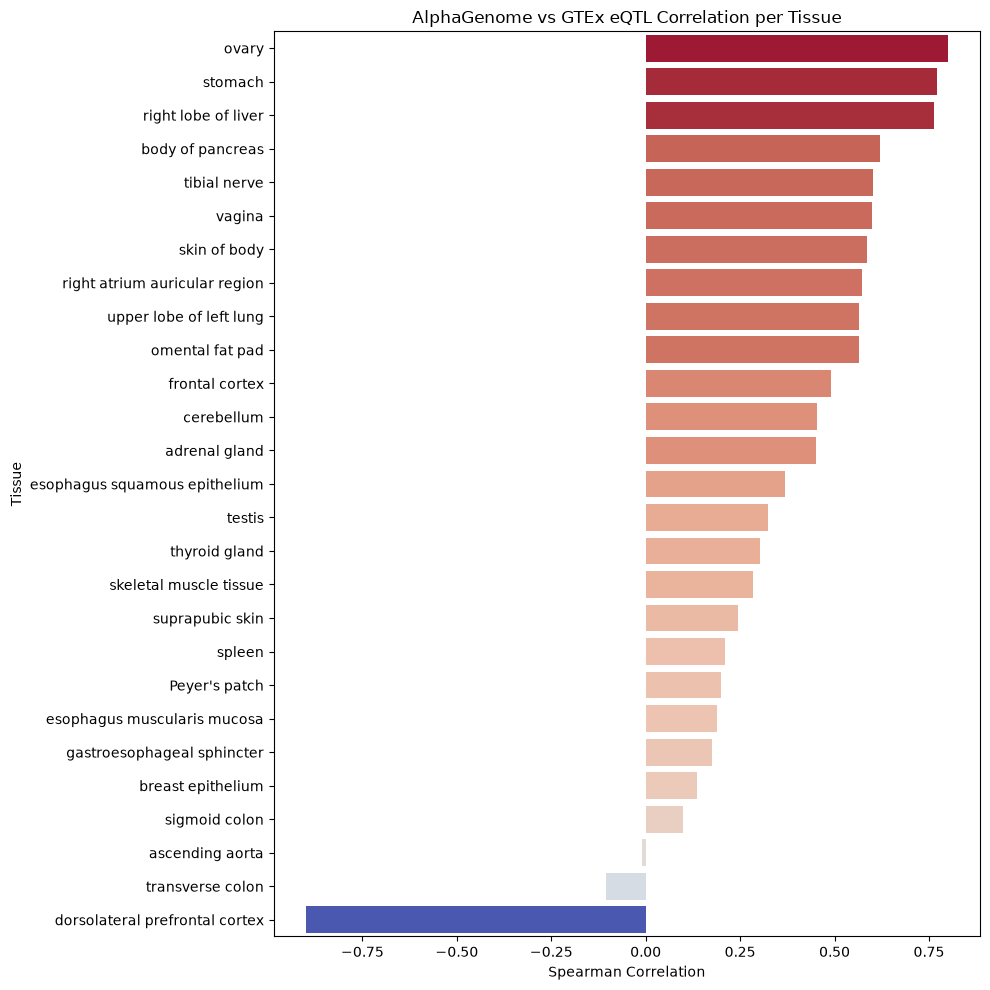

In [14]:
# Calcuate the spearman correlation per tissue
tissue_correlations = {}
for tissue, group in merged_df.groupby('biosample_name'):
    # Check if we have enough points to calculate a meaningful correlation
    if len(group) >= 5:
        corr, p_val = spearmanr(group['beta'], group['raw_score'], nan_policy='omit')
        tissue_correlations[tissue] = (corr, p_val)

# CHANGE: Plot the tissue-specific correlations as a sorted bar chart for better visualization
tc_df = pd.DataFrame.from_dict(tissue_correlations, orient='index', columns=['correlation', 'p_value']).reset_index()
tc_df = tc_df.rename(columns={'index': 'tissue'}).dropna().sort_values('correlation', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='correlation', y='tissue', data=tc_df, palette='coolwarm', hue='correlation', legend=False)
plt.title('AlphaGenome vs GTEx eQTL Correlation per Tissue')
plt.xlabel('Spearman Correlation')
plt.ylabel('Tissue')
plt.tight_layout()
plt.savefig('tissue_correlations.png')

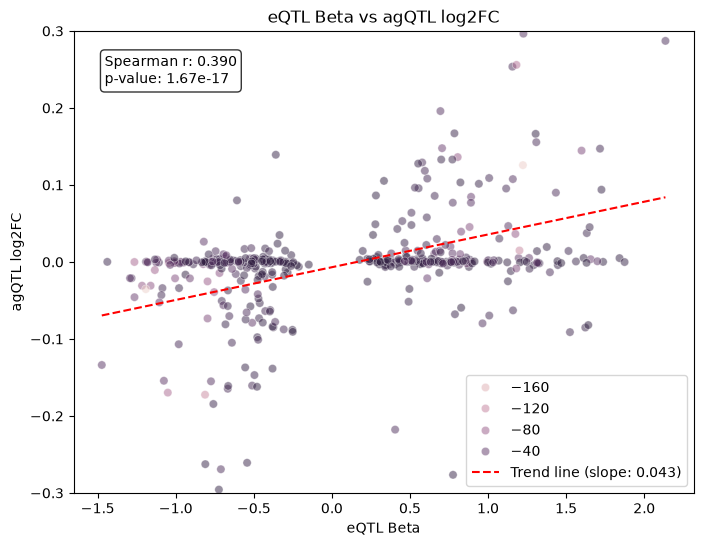

In [15]:
# %% Scatter plot of beta vs log2FC
plt.figure(figsize=(8,6))
# Plot scatter points
sns.scatterplot(x='beta', y='raw_score', hue='pValueExponent', data=merged_df, alpha=0.5)

# CHANGE: Add a trend line (red dashed line) to show positive slope
import numpy as np
m, b = np.polyfit(merged_df['beta'], merged_df['raw_score'], 1)
x_vals = np.linspace(merged_df['beta'].min(), merged_df['beta'].max(), 100)
plt.plot(x_vals, m*x_vals + b, color='red', linestyle='--', label=f'Trend line (slope: {m:.3f})')

plt.title('eQTL Beta vs agQTL log2FC')
plt.xlabel('eQTL Beta')
plt.ylabel('agQTL log2FC')
plt.legend()

# CHANGE: Zoom in on the bulk of the data (ignoring extreme outliers for visual clarity)
plt.ylim(-0.3, 0.3)

# CHANGE: Add text box for correlation metrics on the plot
plt.text(0.05, 0.95, f'Spearman r: {correlation:.3f}\np-value: {p_value:.2e}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# save figure
plt.savefig('beta_vs_log2fc_eqtl_agqtl.png')

Text(0.5, 14.385633680555548, 'ALQTL Direction')

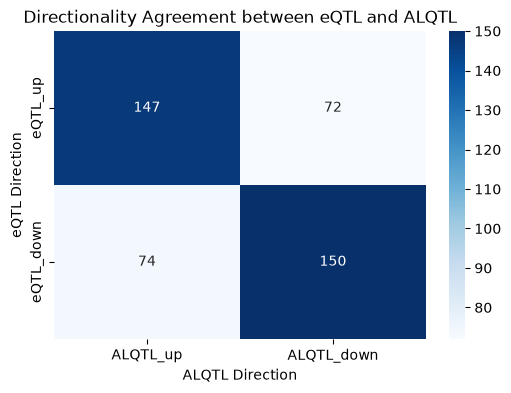

In [16]:
# plot the agreement of the directionality of effect between ALQTL and eQTL
eqtl_dir, alqtl_dir = merged_df['direction'], merged_df['directionality_ag']
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(eqtl_dir, alqtl_dir, labels=['up', 'down'])
cm_df = pd.DataFrame(cm, index=['eQTL_up', 'eQTL_down'], columns=['ALQTL_up', 'ALQTL_down'])
plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Directionality Agreement between eQTL and ALQTL')
plt.ylabel('eQTL Direction')
plt.xlabel('ALQTL Direction')
